# Notebook 2 — Model Architecture & Training

Implements a CNN encoder + LSTM decoder image-captioning model on Flickr8k.

**Fusion method:** Concatenation — at each decoder step the image embedding
and the word embedding are concatenated and projected back to `embed_dim`
before being fed into the LSTM.

**Inputs (from Notebook 1 / data.py):** `train_loader`, `val_loader`, `vocab`  
**Outputs:** `checkpoint_best.pth`, `vocab.pth`, `loss_curves.png`

## 0. Setup

In [16]:
# # Install / upgrade dependencies (Colab-friendly; harmless if already installed)
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "pip", "install", "-q",
#                 "torch", "torchvision", "tqdm", "matplotlib", "datasets",
#                 "pandas", "Pillow"], check=False)

In [17]:
import os, random, math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
import torchvision.models as models
from torchvision.models import ResNet50_Weights
import matplotlib.pyplot as plt
from tqdm import tqdm
from torch.utils.tensorboard import SummaryWriter

# ── reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ── device ───────────────────────────────────────────────────────────────────
DEVICE = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {DEVICE}")

Device: mps


In [18]:
# ── hyperparameters ───────────────────────────────────────────────────────────
EMBED_DIM      = 256
HIDDEN_DIM     = 512
NUM_LAYERS     = 1
DROPOUT        = 0.5
LEARNING_RATE  = 3e-4
BATCH_SIZE     = 32
NUM_EPOCHS     = 20
GRAD_CLIP      = 5.0
FREQ_THRESHOLD = 5
NUM_WORKERS    = 2

## 1. Data Loading

In [19]:
from data import get_loaders

train_loader, val_loader, test_loader, vocab = get_loaders(
    batch_size=BATCH_SIZE,
    freq_threshold=FREQ_THRESHOLD,
    num_workers=NUM_WORKERS,
)

VOCAB_SIZE = len(vocab)
PAD_IDX    = vocab.stoi["<PAD>"]
SOS_IDX    = vocab.stoi["<SOS>"]
EOS_IDX    = vocab.stoi["<EOS>"]

print(f"Vocabulary size : {VOCAB_SIZE}")
print(f"PAD={PAD_IDX}  SOS={SOS_IDX}  EOS={EOS_IDX}")

Loading Flickr8k from HuggingFace (jxie/flickr8k)...
Loaded 40000 caption rows over 8000 images
Unique images   : 8000
  Train images  : 6400  (32000 captions)
  Val   images  : 800  (4000 captions)
  Test  images  : 800  (4000 captions)
Vocabulary size : 2618
Vocabulary size : 2618
PAD=0  SOS=1  EOS=2


/Users/rafal/Documents/projekty/studia/D7047E_Advanced_deep_learning_assignments/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


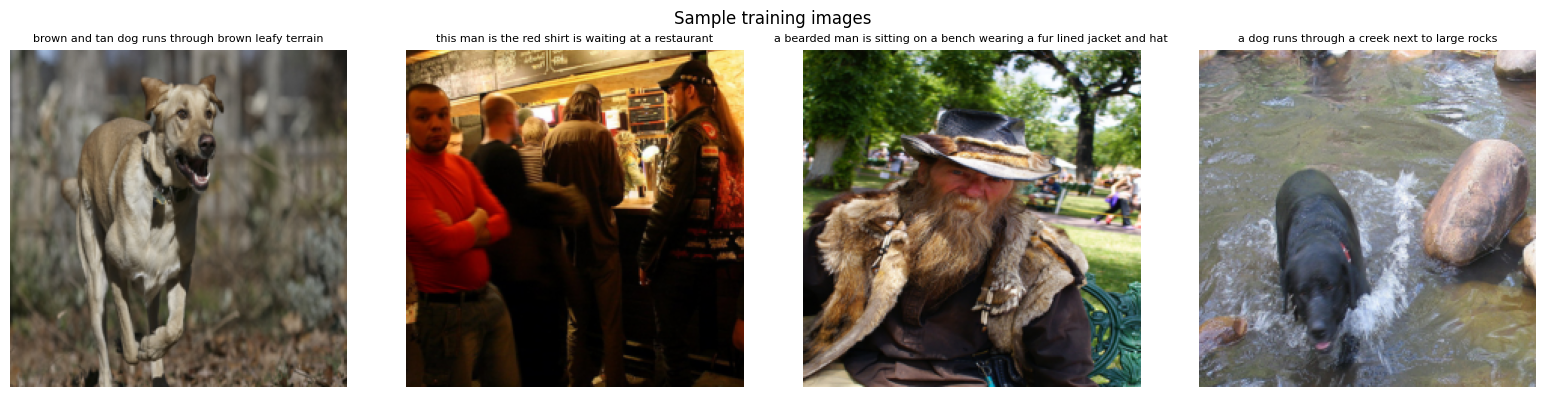

In [20]:
# Visualise 4 training samples
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

imgs, caps, _ = next(iter(train_loader))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    img = (imgs[i] * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    caption = " ".join(
        vocab.itos[t] for t in caps[i].tolist()
        if t not in (PAD_IDX, SOS_IDX, EOS_IDX)
    )
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(caption, fontsize=8, wrap=True)
plt.suptitle("Sample training images", fontsize=12)
plt.tight_layout()
plt.show()

## 2. CNN Encoder

In [21]:
class EncoderCNN(nn.Module):
    """ResNet-50 backbone with the classification head replaced by a
    linear projection to `embed_dim`. Pretrained weights are frozen."""

    def __init__(self, embed_dim: int):
        super().__init__()
        resnet = models.resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
        feature_dim = resnet.fc.in_features          # 2048
        resnet.fc = nn.Identity()                    # strip classification head

        for param in resnet.parameters():
            param.requires_grad = False              # freeze backbone

        self.backbone   = resnet
        self.projection = nn.Linear(feature_dim, embed_dim)
        self.bn         = nn.BatchNorm1d(embed_dim, momentum=0.01)
        self.relu       = nn.ReLU()

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        # images: (B, 3, 224, 224)
        with torch.no_grad():
            features = self.backbone(images)         # (B, 2048)
        out = self.relu(self.bn(self.projection(features)))  # (B, embed_dim)
        return out

In [22]:
# Sanity check
_enc = EncoderCNN(EMBED_DIM).to(DEVICE)
_dummy = torch.zeros(2, 3, 224, 224, device=DEVICE)
_out   = _enc(_dummy)
assert _out.shape == (2, EMBED_DIM), f"Unexpected shape: {_out.shape}"
print(f"EncoderCNN output: {_out.shape}  ✓")
del _enc, _dummy, _out

EncoderCNN output: torch.Size([2, 256])  ✓


## 3. LSTM Decoder

**Fusion — Concatenation:** at each time step the image embedding
*(B, embed_dim)* is expanded and concatenated with the word embedding
*(B, T, embed_dim)* → *(B, T, 2·embed_dim)*, then projected back to
*embed_dim* before entering the LSTM. This preserves the full information
from both modalities without any information loss.

In [23]:
class DecoderLSTM(nn.Module):

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_layers: int,
        dropout: float,
        pad_idx: int,
    ):
        super().__init__()
        self.embed       = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.dropout     = nn.Dropout(dropout)
        # concatenation fusion: image_embed ++ word_embed → embed_dim
        self.fusion_proj = nn.Linear(embed_dim + embed_dim, embed_dim)
        self.lstm        = nn.LSTM(
            embed_dim, hidden_dim, num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc_out      = nn.Linear(hidden_dim, vocab_size)

    def forward(
        self,
        image_embed: torch.Tensor,   # (B, embed_dim)
        captions:    torch.Tensor,   # (B, T)  — teacher-forced inputs
        lengths:     torch.Tensor,   # (B,)    — true sequence lengths
    ) -> torch.Tensor:               # (B, T, vocab_size)

        T = captions.size(1)

        word_embeds = self.dropout(self.embed(captions))          # (B, T, E)
        img_exp     = image_embed.unsqueeze(1).expand(-1, T, -1)  # (B, T, E)

        # concatenation fusion
        fused = torch.cat([img_exp, word_embeds], dim=-1)         # (B, T, 2E)
        fused = self.dropout(F.relu(self.fusion_proj(fused)))     # (B, T, E)

        # pack → LSTM → unpack
        packed = pack_padded_sequence(
            fused, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        lstm_out, _ = self.lstm(packed)                           # packed
        lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True)  # (B, T', H)

        logits = self.fc_out(lstm_out)                            # (B, T', V)
        return logits

In [24]:
# Sanity check
_dec  = DecoderLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, NUM_LAYERS, DROPOUT, PAD_IDX).to(DEVICE)
_img  = torch.zeros(2, EMBED_DIM, device=DEVICE)
_caps = torch.zeros(2, 10, dtype=torch.long, device=DEVICE)
_lens = torch.tensor([10, 8])
_out  = _dec(_img, _caps, _lens)
assert _out.shape == (2, 10, VOCAB_SIZE), f"Unexpected shape: {_out.shape}"
print(f"DecoderLSTM output: {_out.shape}  ✓")
del _dec, _img, _caps, _lens, _out

DecoderLSTM output: torch.Size([2, 10, 2618])  ✓


## 4. Full Model

In [25]:
class CaptioningModel(nn.Module):

    def __init__(
        self,
        vocab_size: int,
        embed_dim: int,
        hidden_dim: int,
        num_layers: int,
        dropout: float,
        pad_idx: int,
    ):
        super().__init__()
        self.encoder = EncoderCNN(embed_dim)
        self.decoder = DecoderLSTM(
            vocab_size, embed_dim, hidden_dim, num_layers, dropout, pad_idx
        )

    def forward(
        self,
        images:   torch.Tensor,  # (B, 3, 224, 224)
        captions: torch.Tensor,  # (B, T)
        lengths:  torch.Tensor,  # (B,)
    ) -> torch.Tensor:
        image_embed = self.encoder(images)                        # (B, E)
        logits      = self.decoder(image_embed, captions, lengths)  # (B, T, V)
        return logits


model = CaptioningModel(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    num_layers=NUM_LAYERS,
    dropout=DROPOUT,
    pad_idx=PAD_IDX,
).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Parameters — trainable: {trainable:,}  /  total: {total:,}")

Parameters — trainable: 4,246,586  /  total: 27,754,618


## 5. Loss, Optimizer, Scheduler

`CrossEntropyLoss(ignore_index=PAD_IDX)` is essential because captions in a
batch are padded to equal length with `<PAD>` tokens. Without `ignore_index`,
the loss would penalise the model for not predicting `<PAD>` at those positions,
which is meaningless — they carry no linguistic content. Setting `ignore_index`
zeroes out the gradient contribution from every `<PAD>` position and excludes
them from the averaging denominator, so the reported loss reflects only real
token predictions.

In [26]:
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=2, factor=0.5
)

print("Criterion, optimizer, scheduler ready.")

Criterion, optimizer, scheduler ready.


In [27]:
writer = SummaryWriter(log_dir="runs/captioning")
print(f"TensorBoard log dir: {os.path.abspath('runs/captioning')}")

TensorBoard log dir: /Users/rafal/Documents/projekty/studia/D7047E_Advanced_deep_learning_assignments/lab3/runs/captioning


## 6. Training Loop

In [28]:
def train_one_epoch(model, loader, optimizer, criterion, device, grad_clip):
    model.train()
    total_loss, n_batches = 0.0, 0

    for imgs, captions, lengths in tqdm(loader, desc="  train", leave=False):
        imgs     = imgs.to(device)
        captions = captions.to(device)

        inputs  = captions[:, :-1]
        targets = captions[:, 1:]
        inp_len = (lengths - 1).clamp(min=1)

        logits = model(imgs, inputs, inp_len)

        T = min(logits.size(1), targets.size(1))
        loss = criterion(
            logits[:, :T, :].reshape(-1, VOCAB_SIZE),
            targets[:, :T].reshape(-1),
        )

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        optimizer.step()

        total_loss += loss.item()
        n_batches  += 1

    return total_loss / max(n_batches, 1)


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, n_batches = 0.0, 0

    for imgs, captions, lengths in tqdm(loader, desc="  val  ", leave=False):
        imgs     = imgs.to(device)
        captions = captions.to(device)

        inputs  = captions[:, :-1]
        targets = captions[:, 1:]
        inp_len = (lengths - 1).clamp(min=1)

        logits = model(imgs, inputs, inp_len)

        T = min(logits.size(1), targets.size(1))
        loss = criterion(
            logits[:, :T, :].reshape(-1, VOCAB_SIZE),
            targets[:, :T].reshape(-1),
        )
        total_loss += loss.item()
        n_batches  += 1

    return total_loss / max(n_batches, 1)


print("train_one_epoch and evaluate defined.")

train_one_epoch and evaluate defined.


In [29]:
train_losses, val_losses = [], []
best_val_loss = math.inf
CHECKPOINT_PATH = "checkpoint_best.pth"

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, DEVICE, GRAD_CLIP
    )
    val_loss = evaluate(model, val_loader, criterion, DEVICE)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch:02d}/{NUM_EPOCHS} "
        f"| train_loss: {train_loss:.4f} "
        f"| val_loss: {val_loss:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {
                "epoch":           epoch,
                "model_state":     model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_loss":        val_loss,
                "vocab":           vocab,
                "hparams": {
                    "embed_dim":  EMBED_DIM,
                    "hidden_dim": HIDDEN_DIM,
                    "num_layers": NUM_LAYERS,
                    "dropout":    DROPOUT,
                },
            },
            CHECKPOINT_PATH,
        )
        print(f"  → saved checkpoint (val_loss={best_val_loss:.4f})")

print(f"\nTraining complete. Best val_loss: {best_val_loss:.4f}")

KeyboardInterrupt: 

## 7. Training Curves

In [ ]:
epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_losses, label="Train loss", marker="o", markersize=3)
plt.plot(epochs, val_losses,   label="Val loss",   marker="s", markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")
plt.title("Image Captioning — Training & Validation Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("loss_curves.png", dpi=150)
plt.show()
print("Saved: loss_curves.png")

In [ ]:
# Verify both curves are decreasing (assignment requirement)
assert train_losses[-1] < train_losses[0], (
    f"Train loss did not decrease: {train_losses[0]:.4f} → {train_losses[-1]:.4f}"
)
assert val_losses[-1] < val_losses[0], (
    f"Val loss did not decrease: {val_losses[0]:.4f} → {val_losses[-1]:.4f}"
)
print(f"Train loss: {train_losses[0]:.4f} → {train_losses[-1]:.4f}  ✓ decreasing")
print(f"Val   loss: {val_losses[0]:.4f} → {val_losses[-1]:.4f}  ✓ decreasing")

## 8. Save Artifacts

In [ ]:
torch.save(vocab, "vocab.pth")
print(f"vocab.pth saved  (vocab size: {len(vocab)})")
print(f"checkpoint_best.pth saved  (best val_loss: {best_val_loss:.4f})")
assert os.path.exists("checkpoint_best.pth")
assert os.path.exists("vocab.pth")
print("Both artefacts present on disk ✓")